<a href="https://colab.research.google.com/github/broistg/ML-Assignment-DNAC1/blob/main/notebooks/BTL3_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0.&nbsp;User manual

This Google Colab file implements a deep learning pipeline for an image dataset (CIFAR-10). To run this notebook, do the following:
- Select the confiuration you want in the cell below (default: fine tuning DistilBERT model).
- After that click the Colab `Run all` button (library installation and dataset loading are automated).
- The pipeline will run according to your configuration.
- See the final result in the last cell of this notebook.

If you want to rerun the pipeline with another configuration, you only need to run the last cell again after selecting your config.

# 1.&nbsp;Prepare the necessary data and libraries

## 1.1.&nbsp;Verify and install necessary libraries

In [1]:
import sys
import subprocess
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset as TorchDataset
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.models as models

def pip_install(packages):
    """Installs packages quietly."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + packages)

pip_install(["scikit-learn", "pandas", "matplotlib", "seaborn", "torch", "torchvision", "tqdm"])

In [2]:
RND = 42
np.random.seed(RND)
random.seed(RND)
torch.manual_seed(RND)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RND)

CONFIG = {
    'model_name': 'swin',
    'resize_dim': 224,
    'batch_size': 64,
    'learning_rate': 3e-4,
    'num_epochs': 10
}

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
NUM_CLASSES = len(CLASS_NAMES)

Using device: cuda


## 1.2.&nbsp;Download and store the dataset

In [3]:
print("Downloading CIFAR-10 dataset and creating DataLoaders...")

transform_train = transforms.Compose([
    transforms.Resize(CONFIG['resize_dim']),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val_test = transforms.Compose([
    transforms.Resize(CONFIG['resize_dim']),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_full_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform_val_test
)

# Split full training data into train and validation (85% / 15%)
train_size = int(0.85 * len(train_full_dataset))
val_size = len(train_full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    train_full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(RND)
)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=2
)
val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2
)
test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2
)

print(f"\nTotal training images: {len(train_full_dataset)}")
print(f"Split -> Train: {len(train_dataset)}, Validation: {len(val_dataset)}, Test: {len(test_dataset)}")

100%|██████████| 170M/170M [00:14<00:00, 11.9MB/s]



Total training images: 50000
Split -> Train: 42500, Validation: 7500, Test: 10000



--- Starting EDA ---
Image shape (after transform): torch.Size([64, 3, 224, 224])
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


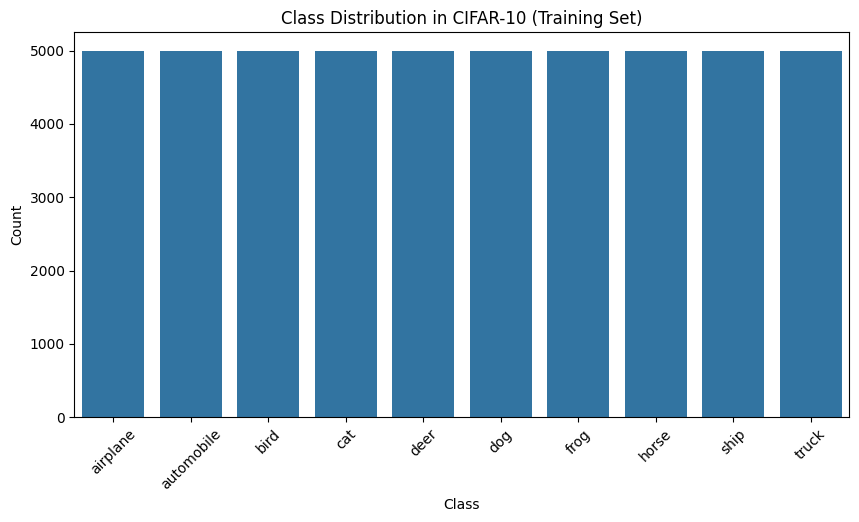


Displaying sample images (from validation set)...


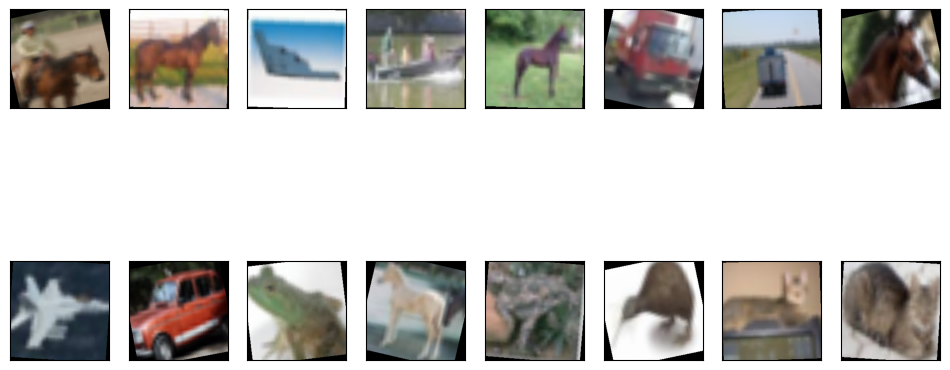

--- EDA Finished ---


In [4]:
print("\n--- Starting EDA ---")
print(f"Image shape (after transform): {next(iter(train_loader))[0].shape}")
print(f"Classes: {CLASS_NAMES}")

label_counts = pd.Series(train_full_dataset.targets).value_counts().sort_index()
label_counts.index = CLASS_NAMES

plt.figure(figsize=(10, 5))
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title('Class Distribution in CIFAR-10 (Training Set)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print("\nDisplaying sample images (from validation set)...")

def imshow(img_batch):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_batch = img_batch.numpy().transpose((0, 2, 3, 1))
    img_batch = std * img_batch + mean
    img_batch = np.clip(img_batch, 0, 1)

    plt.figure(figsize=(12, 6))
    for i in range(min(16, len(img_batch))):
        plt.subplot(2, 8, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(img_batch[i])
    plt.show()

images, labels = next(iter(val_loader))
imshow(images)
print("--- EDA Finished ---")

# 2.&nbsp;VGG16

In [5]:
def VGG_train_and_test(lr=0.001, num_epochs=10):
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    for param in model.features.parameters():
        param.requires_grad = False

    model.classifier[6] = nn.Linear(4096, 10)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Acc: {acc:.2f}%")


    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    print(f"Test Accuracy: {100. * correct / total:.2f}%")

# 3.&nbsp;ResNet18

In [6]:
def ResNet_train_and_test(lr=0.001, num_epochs=10):
    resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    num_ftrs = resnet.fc.in_features
    resnet.fc = nn.Linear(num_ftrs, 10)
    resnet = resnet.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(resnet.parameters(), lr=lr)

    for epoch in range(num_epochs):
        resnet.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = resnet(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Acc: {acc:.2f}%")

    resnet.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    print(f"Test Accuracy: {100. * correct / total:.2f}%")

# 4.&nbsp;EfficientNet-B0

In [7]:
def B0_train_and_test(lr=0.001, num_epochs=10):
    efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

    num_ftrs = efficientnet.classifier[1].in_features
    efficientnet.classifier[1] = nn.Linear(num_ftrs, 10)
    efficientnet = efficientnet.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(efficientnet.parameters(), lr=lr)

    for epoch in range(num_epochs):
        efficientnet.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = efficientnet(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Acc: {acc:.2f}%")

    efficientnet.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = efficientnet(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    print(f"Test Accuracy: {100. * correct / total:.2f}%")

# 5.&nbsp;Vision Transformer (ViT)

In [8]:
import timm

def ViT_train_and_test(lr=3e-5, num_epochs=10):
    model = timm.create_model('vit_base_patch16_224', pretrained=True)
    for param in model.parameters():
        param.requires_grad = False

    model.head = nn.Linear(model.head.in_features, 10)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.head.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Acc: {acc:.2f}%")

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    print(f"Test Accuracy: {100. * correct / total:.2f}%")

# 6.&nbsp;Swin Transformer

In [9]:
def Swin_train_and_test(lr=3e-4, num_epochs=10):
    model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True)

    model.head = nn.Linear(model.head.in_features, 10)  # CIFAR10 có 10 lớp
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            outputs = outputs.view(outputs.size(0), -1)
            labels = labels.view(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}, Acc: {acc:.2f}%")

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    print(f"Test Accuracy: {100. * correct / total:.2f}%")

In [ ]:
if CONFIG['model_name'] == 'vgg16':
  VGG_train_and_test(CONFIG['learning_rate'], CONFIG['num_epochs'])
elif CONFIG['model_name'] == 'resnet18':
  ResNet_train_and_test(CONFIG['learning_rate'], CONFIG['num_epochs'])
elif CONFIG['model_name'] == 'efficientnet_b0':
  B0_train_and_test(CONFIG['learning_rate'], CONFIG['num_epochs'])
elif CONFIG['model_name'] == 'vit':
  ViT_train_and_test(CONFIG['learning_rate'], CONFIG['num_epochs'])
elif CONFIG['model_name'] == 'swin':
  Swin_train_and_test(CONFIG['learning_rate'], CONFIG['num_epochs'])
else:
  raise ValueError(f"Model '{CONFIG['model_name']}' is not supported yet.")